## Analysis of Machine Learning (ML) Applications on HuggingFace Store

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import plotly.express as px
from pathlib import Path
from itertools import zip_longest
from huggingface_hub import HfApi

In [82]:
# initializes HuggingFace Hub API
api = HfApi()

In [1]:
200/1000

0.2

## Data Collection - Part 1

Obtain a list of the top-20 "Text Classification" and top-20 "Text Generation" models on https://huggingface.co/, ranked based on the total number of downloads. 

In [3]:
def get_top_n_model_names(n, filter_str, sort_by):
    """
    returns a list of model names of the selected top n models
    n (int): number of models to retrieve
    filter_str (str): a keyword which is used to filter models
    sort_by (str): the sorting method
    """
    model_names = []
    
    for m in api.list_models(
        filter=filter_str,
        sort=sort_by,
        direction=-1,  # sort by descending order
        limit=n
    ):
        model_names.append(m.id)
        
    return model_names

#### Obtain the list of top 20 “Text Generation” models

In [4]:
gen_model_names = get_top_n_model_names(20, "text-generation", "downloads")

gen_model_names

['distilgpt2',
 'gpt2',
 'davidkim205/komt-mistral-7b-v1',
 'tiiuae/falcon-40b-instruct',
 'bigscience/bloom-560m',
 'petals-team/StableBeluga2',
 'meta-llama/Llama-2-7b-chat-hf',
 'facebook/opt-1.3b',
 'HuggingFaceM4/tiny-random-LlamaForCausalLM',
 'facebook/opt-125m',
 'microsoft/git-base',
 'TheBloke/CodeLlama-34B-Instruct-GPTQ',
 'mistralai/Mistral-7B-Instruct-v0.1',
 'mistralai/Mistral-7B-v0.1',
 'meta-llama/Llama-2-7b-hf',
 'gpt2-medium',
 'TheBloke/Llama-2-7B-Chat-GPTQ',
 'NousResearch/Nous-Hermes-Llama2-13b',
 'gpt2-large',
 'meta-llama/Llama-2-13b-chat-hf']

#### Obtain the list of top 20 "Text Classification" models

In [5]:
cla_model_names = get_top_n_model_names(20, "text-classification", "downloads")

cla_model_names

['distilbert-base-uncased-finetuned-sst-2-english',
 'cardiffnlp/twitter-roberta-base-irony',
 'lxyuan/distilbert-base-multilingual-cased-sentiments-student',
 'mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis',
 'SamLowe/roberta-base-go_emotions',
 'marieke93/MiniLM-evidence-types',
 'Ashishkr/query_wellformedness_score',
 'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
 'cardiffnlp/twitter-roberta-base-sentiment',
 'facebook/bart-large-mnli',
 'cardiffnlp/twitter-roberta-base-sentiment-latest',
 'nlptown/bert-base-multilingual-uncased-sentiment',
 'cardiffnlp/twitter-xlm-roberta-base-sentiment',
 'papluca/xlm-roberta-base-language-detection',
 'ProsusAI/finbert',
 'cross-encoder/ms-marco-TinyBERT-L-2-v2',
 'cross-encoder/ms-marco-MiniLM-L-4-v2',
 'martin-ha/toxic-comment-model',
 'alexandrainst/scandi-nli-large',
 'laiyer/deberta-v3-base-prompt-injection']

### Data Validation - Check if the 2 groups of models are independent

In [87]:
# check if the intersection between two groups of models is empty 

gen_model_name_set = set(gen_model_names)
cla_model_name_set = set(cla_model_names)
gen_model_name_set.intersection(cla_model_name_set) == set()

True

In [92]:
# check if there are any overlapping values in two groups

len(gen_model_name_set - cla_model_name_set) == 20
len(cla_model_name_set - gen_model_name_set) == 20

True

## Data Collection - Part 2
Obtain and compare the number of ML apps ("spaces") for each "Text Classification" and "Text Generation" model obtained in Part 1.

In [11]:
def get_spaces(model_names):
    """
    get the number of spaces for a list of model names provided
    model_names (list[str]): a list of model names
    """
    spaces = {}

    for n in model_names:
        spaces[n] = []
        for s in api.list_spaces(
            models=n,
            full=False
        ):
            spaces[n].append(s.id)

    return spaces

#### Obtain a dictionary with the specific spaces developed for each "Text Generation" model

In [12]:
gen_spaces = get_spaces(gen_model_names)

gen_spaces

{'distilgpt2': ['Amrrs/image-caption-with-vit-gpt2',
  'Endre/SemanticSearch-HU',
  'OOlajide/common-nlp-tasks',
  'Sakil/essay_generator_app',
  'akhaliq/SummerTime',
  'aliabd/SummerTime',
  'aubmindlab/Arabic-NLP',
  'docs-demos/gpt2',
  'flax-community/indonesian-image-captioning',
  'flax-community/multilingual-image-captioning',
  'flax-community/spanish-image-captioning',
  'flax-community/t5-vae',
  'Aanisha/Image_to_story',
  'Ezi/ModelCardsAnalysis',
  'abxhr/design-project',
  'Gradio-Blocks/pokemon-move-generator-app',
  'tinkoff-ai/caif',
  'AhmedSSabir/demo-for-Visual-Belief-Revision',
  'sasha/WinoBiasCheck',
  'alistairmcleay/cambridge-masters-project',
  'AhmedSSabir/Demo-for-Gender-Score',
  'AhmedSSabir/demo-for-Visual-Re-ranker',
  'AhmedSSabir/Demo-for-Gender-Score-jp',
  'sasha/BiasDetection',
  'freddyaboulton/generate-english-german',
  'smjain/gpt2_text_gen',
  'freddyaboulton/all_demos',
  'ccolas/TastyPiano',
  'eliwill/MVP-1.1',
  'canonsky1992/distilgpt2',


#### Display a bar chart to show the number of spaces for each "Text Generation" model

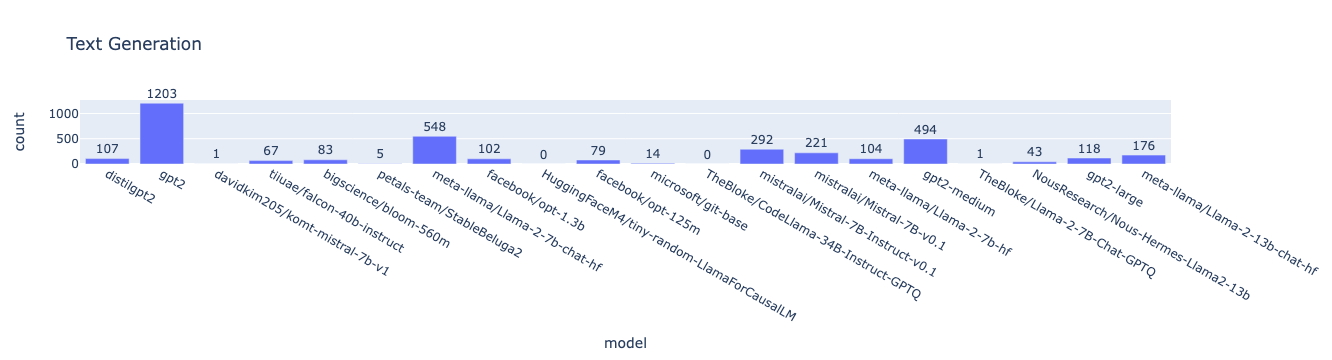

In [125]:
# convert dict for plotting the bar chart

gen_space_count = {
    "model": [],
    "count": []
}

for m, s in gen_spaces.items():
    gen_space_count["model"].append(m)
    gen_space_count["count"].append(len(s))

# from left to right, the number of downloads is decreasing, as order is preserved

fig = px.bar(
    gen_space_count, y="count", x="model", text_auto=True,
    labels={"x": "Models", "y": "Space Count"},
    title="Text Generation", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

#### Obtain a dictionary with the specific spaces developed for each "Text Classification" model

In [119]:
cla_spaces = get_spaces(cla_model_names)

cla_spaces

{'distilbert-base-uncased-finetuned-sst-2-english': ['Endre/SemanticSearch-HU',
  'chinhon/Speech_Sentiment_Analysis',
  'chinhon/sentiment_structure_visualiser',
  'justheuristic/ysda-demo',
  'ANDRYHA/FakeNewsClassifier',
  'nazneen/interactive-model-cards',
  'ayse/sentiment-classifier',
  'abidlabs/call-sentiment-blocks-2',
  'nazneen/error-analysis',
  'autoevaluate/error-analysis',
  'butterswords/nlc-explorer',
  'tinkoff-ai/caif',
  'husnu/ASR_to_QA',
  'ombhagwat24/senti',
  'greco/survey_analytics_spaces',
  'Saurav21/Sentiment-Analysis',
  'EnzoBustos/IC-2022-Classificacao-de-Dados-Financeiros',
  'rajistics/interpet_transformers',
  'nazneen/seal',
  'CK42/sentiment-model-comparison',
  'ccolas/TastyPiano',
  'codesue/dystopedia',
  'anonymous8/Rapid-Textual-Adversarial-Defense',
  'pattawat/stat_ds__02',
  'Jindong/test123',
  'fxmarty/bettertransformer-demo',
  'TangibleAI/mathtext',
  'Booguy/linguask',
  'fabiochiu/sentiment-analysis-demo',
  'mattaylor/embedding',
  'u

#### Display a bar chart to show the number of spaces for each "Text Classfication" model

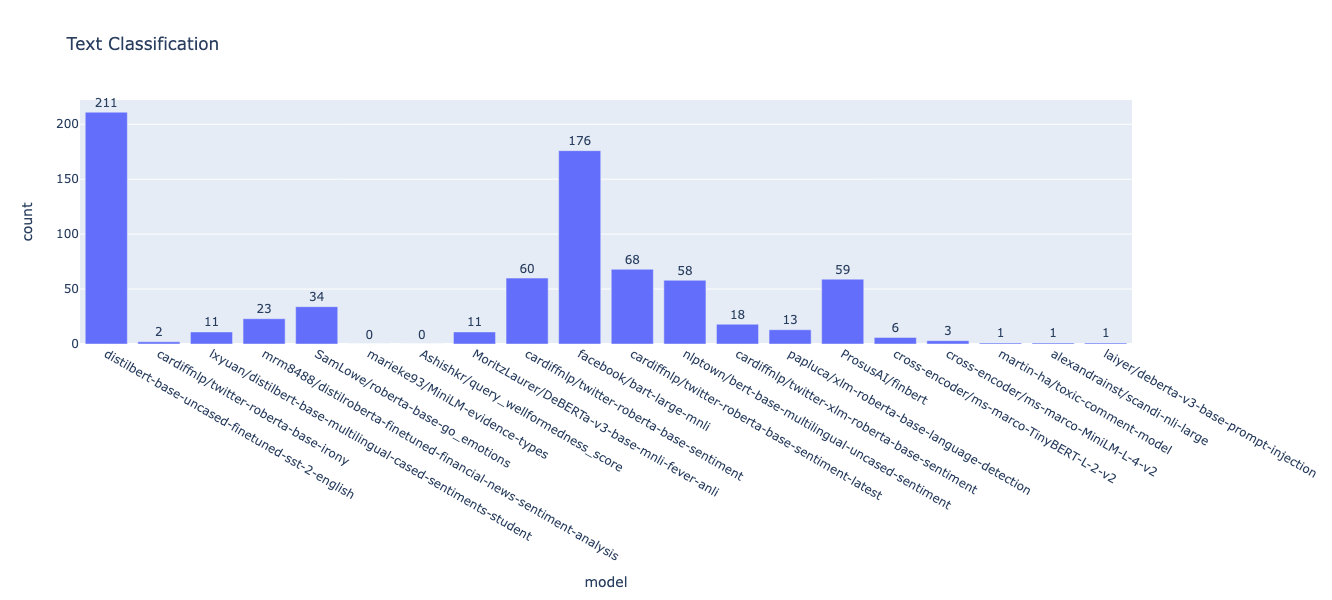

In [126]:
# convert dict for plotting the bar chart

cla_space_count = {
    "model": [],
    "count": []
}

for m, s in cla_spaces.items():
    cla_space_count["model"].append(m)
    cla_space_count["count"].append(len(s))

# from left to right, the number of downloads is decreasing, as order is preserved

fig = px.bar(
    cla_space_count, y="count", x="model", text_auto=True,
    labels={"x": "Models", "y": "Space Count"},
    title="Text Classification", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

#### Check if the two groups of spaces are perfectly mutuall exclusive
Check if there are any spaces used both ML models from "Text-Generation" and "Text-Classification"

In [127]:
# create a list for storing overlap spaces used in both groups

space_intersection = []

for c in cla_model_names:
    for g in gen_model_names:
        intersection_list = api.list_spaces(
            models=[c, g],
            full=False
        )
        if len(list(intersection_list)) > 0:
            space_intersection.append((c, g))

space_intersection

[('distilbert-base-uncased-finetuned-sst-2-english', 'distilgpt2'),
 ('distilbert-base-uncased-finetuned-sst-2-english', 'gpt2'),
 ('distilbert-base-uncased-finetuned-sst-2-english',
  'meta-llama/Llama-2-7b-chat-hf'),
 ('distilbert-base-uncased-finetuned-sst-2-english',
  'mistralai/Mistral-7B-v0.1'),
 ('distilbert-base-uncased-finetuned-sst-2-english', 'gpt2-medium'),
 ('distilbert-base-uncased-finetuned-sst-2-english', 'gpt2-large'),
 ('facebook/bart-large-mnli', 'gpt2'),
 ('facebook/bart-large-mnli', 'gpt2-medium'),
 ('cardiffnlp/twitter-roberta-base-sentiment-latest', 'distilgpt2'),
 ('cardiffnlp/twitter-roberta-base-sentiment-latest', 'gpt2'),
 ('cross-encoder/ms-marco-TinyBERT-L-2-v2',
  'mistralai/Mistral-7B-Instruct-v0.1')]

## Check Data Distribution
### Plot a Histogram to display the distribution of the number of spaces with "Text-Generation" models
#### Result: it is not a bell-shaped curve, so data is not normally distributed

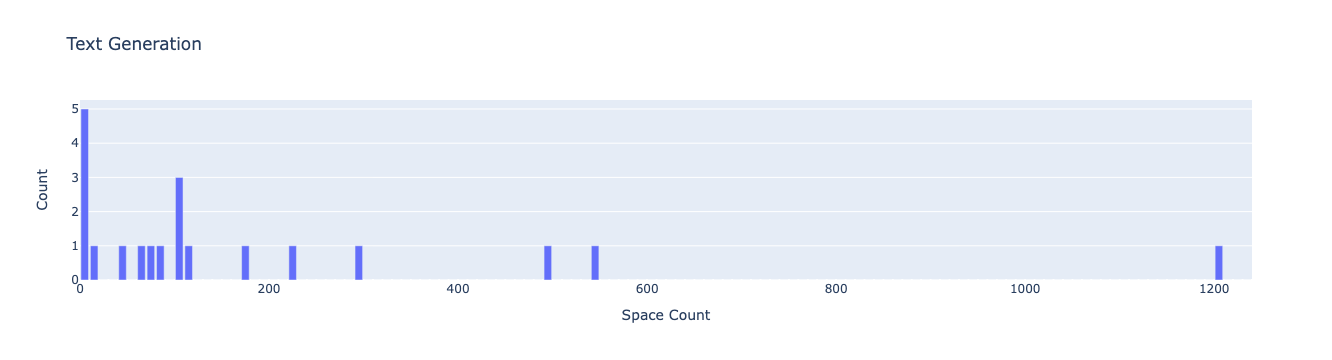

In [95]:
# create the bins to visualize the distribution of the number of space

counts, bins = np.histogram(gen_space_count["count"], bins=range(0, 1250, 10))
bins = 0.5 * (bins[: -1] + bins[1: ])

fig = px.bar(
    x=bins, y=counts, labels={"x": "Space Count", "y": "Count"},
    title="Text Generation", height=600
)
fig.show()

### Use Shapiro-Wilk test the distribution of the number of spaces with "Text-Generation" models
#### Result: p-value is significant (p < 0.05), so data is not normally distributed

In [133]:
gen_w, gen_pvalue = stats.shapiro(gen_space_count["count"])
gen_w, gen_pvalue

(0.6465062499046326, 9.293078619521111e-06)

### Plot a Histogram to display the distribution of the number of spaces with "Text-Classification" models
#### Result: it is not a bell-shaped curve, so data is not normally distributed

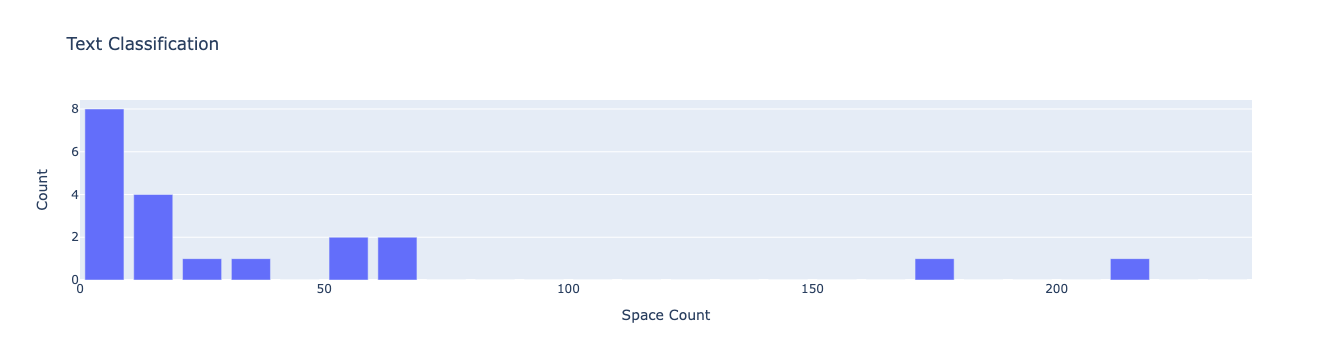

In [98]:
# create the bins to visualize the distribution of the number of space

counts, bins = np.histogram(cla_space_count["count"], bins=range(0, 250, 10))
bins = 0.5 * (bins[: -1] + bins[1: ])

fig = px.bar(
    x=bins, y=counts, labels={"x": "Space Count", "y": "Count"},
    title="Text Classification", height=600
)
fig.show()

### Use Shapiro-Wilk test the distribution of the number of spaces with "Text-Classification" models
#### Result: p-value is significant (p < 0.05), so data is not normally distributed

In [134]:
cla_w, cla_pvalue = stats.shapiro(cla_space_count["count"])
cla_w, cla_pvalue

(0.670326828956604, 1.7317319361609407e-05)

## Data Analysis - Part 2
#### Compare the total number of spaces developed using "Text Generation" models and using "Text Classification" models

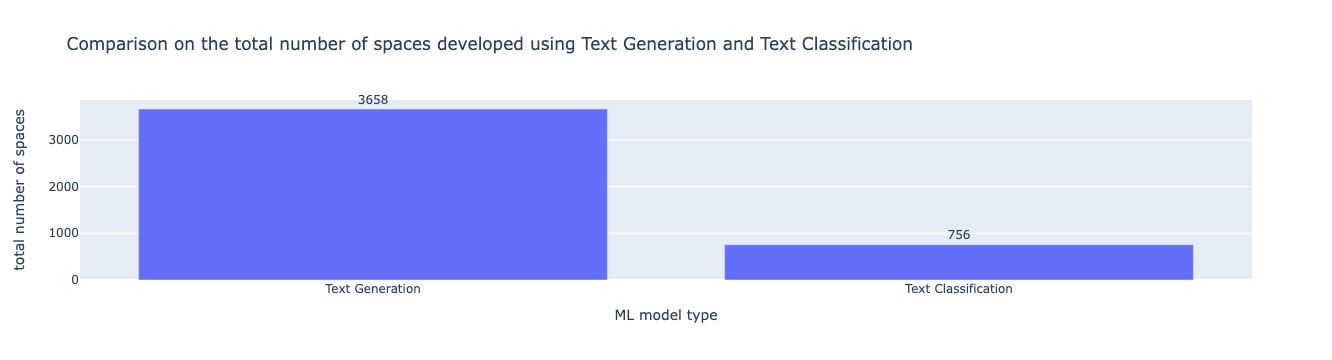

In [116]:
# get the total number of spaces developed using "Text Generation" models

total_gen_spaces = 0
for m, s in gen_spaces.items():
    total_gen_spaces += len(s)

# get the total number of spaces developed using "Text Classification" models

total_cla_spaces = 0
for m, s in cla_spaces.items():
    total_cla_spaces += len(s)

# plot a bar chart to show the difference of the total number of spaces developed using the two groups of models

total_space_count = {
    "ML model type": ["Text Generation", "Text Classification"],
    "total number of spaces": [total_gen_spaces, total_cla_spaces]
}

fig = px.bar(
    total_space_count, y="total number of spaces", x="ML model type", text_auto=True,
    labels={"x": "Models", "y": "Space Count"},
    title="Comparison on the total number of spaces developed using Text Generation and Text Classification", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()


#### Use Mann-Whitney U test to compare the number of spaces developed using "Text Generation" models and using "Text Classification" models
#### Result: p-value obtained from the Mann-Whitney U test is significant (U = 284.5, p < 0.05), I conclude that the number of ML applications developed using "Text Generation" models is much larger than using  "Text Classification" models

In [136]:
"""
perform one-tailed test to test whether the number of ML applications 
developed using "Text Generation" models are much larger than using  "Text Classification" models
"""

stats.mannwhitneyu(
    x=gen_space_count["count"], 
    y=cla_space_count["count"], 
    alternative="greater"
)

MannwhitneyuResult(statistic=284.5, pvalue=0.011434213299653292)

## Data Collection - Part 3

#### Obtain and compare the source code size of the ML apps ("spaces") obtained in Part 2.

In [22]:
def get_space_size(space_id, api, skipped_suffix_list=None):
    """
    return each space size in bytes
    
    space_id (str): space id
    api (HfApi): hub api
    skipped_suffix_list (list[str] | None): file path suffix to filter and remove, case sensitive
    """
    total_size = 0
    suffixes = []

    for f in api.list_files_info(
        repo_id=space_id, 
        repo_type="space"
    ):
        if skipped_suffix_list:
            f_path = Path(f.path)
            # suffix is not empty and not in the exclusion list
            if (f_suffix := f_path.suffix) and f_suffix not in skipped_suffix_list:  
                total_size += f.size

            # suffix is empty and not in the exclusion list
            elif not f_suffix and f_path.name not in skipped_suffix_list:  
                total_size += f.size
        else:
            f_path = Path(f.path)
            if (f_suffix := f_path.suffix):
                suffixes.append(f_suffix)
            else:
                suffixes.append(f_path)
            
            total_size += f.size
    return total_size, suffixes

#### Get the total size of the source code repositories developed with "Text Classification" models

In [122]:
cla_sizes = {}
cla_suffixes = []

for s_list in cla_spaces.values():
    for s in s_list:
        total_size, suffixes = get_space_size(s, api, [".md", ".png", ".jpeg", ".jpg", ".mp4", ".mp3", "LICENSE", ".DS_Store"])
        cla_sizes[s] = total_size
        cla_suffixes.extend(suffixes)

In [124]:
cla_sizes

{'Endre/SemanticSearch-HU': 1028246356,
 'chinhon/Speech_Sentiment_Analysis': 4070,
 'chinhon/sentiment_structure_visualiser': 5558,
 'justheuristic/ysda-demo': 1775,
 'ANDRYHA/FakeNewsClassifier': 267914900,
 'nazneen/interactive-model-cards': 27710231,
 'ayse/sentiment-classifier': 3038,
 'abidlabs/call-sentiment-blocks-2': 3300186,
 'nazneen/error-analysis': 366221522,
 'autoevaluate/error-analysis': 366220769,
 'butterswords/nlc-explorer': 3310576,
 'tinkoff-ai/caif': 27945,
 'husnu/ASR_to_QA': 6430,
 'ombhagwat24/senti': 1867,
 'greco/survey_analytics_spaces': 88920985,
 'Saurav21/Sentiment-Analysis': 2023,
 'EnzoBustos/IC-2022-Classificacao-de-Dados-Financeiros': 637268217,
 'rajistics/interpet_transformers': 5476,
 'nazneen/seal': 543409107,
 'CK42/sentiment-model-comparison': 4585,
 'ccolas/TastyPiano': 715556962,
 'codesue/dystopedia': 4281,
 'anonymous8/Rapid-Textual-Adversarial-Defense': 2479222161,
 'pattawat/stat_ds__02': 1867,
 'Jindong/test123': 10025,
 'fxmarty/bettertr

In [26]:
set(cla_suffixes)

{'.0',
 '.1',
 '.2',
 '.3',
 PosixPath('.DS_Store'),
 '.MD',
 '.PNG',
 PosixPath('.Rhistory'),
 '.backup',
 '.bash',
 '.bat',
 '.bin',
 '.cfg',
 '.ckpt',
 '.command',
 '.cpp',
 '.cpu',
 '.css',
 '.csv',
 '.cu',
 '.cuh',
 '.dat',
 '.db',
 '.dill',
 '.doc2vec',
 PosixPath('.dockerignore'),
 '.env',
 PosixPath('.env-sample'),
 '.example',
 '.feather',
 PosixPath('.fhe_keys/.gitkeep'),
 '.flac',
 PosixPath('.flake8'),
 '.gif',
 PosixPath('.gitattributes'),
 PosixPath('.gitignore'),
 PosixPath('.gitignore~'),
 PosixPath('.gitmodules'),
 '.glb',
 '.gpu',
 '.h',
 '.h5',
 '.html',
 '.ico',
 PosixPath('.idea/.gitignore'),
 '.idx',
 '.iml',
 '.in',
 '.ini',
 '.ipynb',
 '.j2',
 '.joblib',
 '.jpeg',
 '.jpg',
 '.js',
 '.json',
 '.jsonl',
 '.lance',
 '.lock',
 '.manifest',
 '.map',
 '.md',
 PosixPath('.md'),
 '.md~',
 '.md~ 2',
 '.mid',
 '.model',
 '.mp3',
 '.mp4',
 '.npy',
 '.npz',
 '.obj',
 '.onnx',
 '.p',
 '.parquet',
 '.pdf',
 '.pem',
 '.pickle',
 '.pkl',
 '.png',
 '.pptx',
 '.praat',
 '.prompt'

In [29]:
 PosixPath('.DS_Store'),
 '.MD',
 '.PNG',
 PosixPath('.Rhistory'),
 '.backup',
 '.example',
 '.flac',
 '.gif',
 '.ico',
 '.jpeg',
 '.jpg',
 '.md',
 PosixPath('.md'),
 '.md~',
 '.md~ 2',
 '.mid',
 '.mp3',
 '.mp4',
 '.pdf',
 '.png',
 '.pptx',
 '.pyc',
 '.rst',
 '.rst_t',
 '.svg',
 '.tf',
 '.un~',
 '.wav',
 '.webp',
 '.wsd',
 PosixPath('Assets/.DS_Store'),
 PosixPath('CICD/.DS_Store'),
 PosixPath('LICENSE'),
 PosixPath('LICENSE_weights'),
 PosixPath('assets/.DS_Store'),
 PosixPath('buildManagement/.DS_Store'),
 PosixPath('cicd/LICENSE'),
 PosixPath('interactive_model_cards/.DS_Store'),
 PosixPath('models/.DS_Store'),
 PosixPath('models/roberta-large/.DS_Store'),
 PosixPath('models/roberta-large/runs/.DS_Store'),
 PosixPath('models/roberta-large/runs/May10_08-20-25_aa60e833fd05/.DS_Store'),
 PosixPath('sounds/redme'),
 PosixPath('src/music/representation_learning/sentence_transfo/LICENSE'),
 PosixPath('static/full/empty'),
 PosixPath('static/previews/empty'),
 PosixPath('static/temp/empty'),
 PosixPath('swarms/agents/.DS_Store'),
 PosixPath('swarms/agents/models/segment_anything/LICENSE'),
 PosixPath('unitTest/.DS_Store'),

NameError: name 'PosixPath' is not defined

In [30]:
gen_sizes = {}
gen_suffixes = []

for s_list in gen_spaces.values():
    for s in s_list:
        total_size, suffixes = get_space_size(s, api)
        gen_sizes[s] = total_size
        gen_suffixes.extend(suffixes)

In [32]:
set(gen_suffixes)

{PosixPath('installer_files/env/share/terminfo/w/wyse-75ap'),
 PosixPath('installer_files/conda/pkgs/toolz-0.12.0-py310haa95532_0/Lib/site-packages/toolz-0.12.0.dist-info/WHEEL'),
 PosixPath('venv/Lib/python3.10/site-packages/pytz/zoneinfo/America/Porto_Velho'),
 PosixPath('venv/lib/python3.11/site-packages/pytz/zoneinfo/Etc/GMT+0'),
 PosixPath('venv/lib/python3.11/site-packages/tzdata/zoneinfo/America/Chicago'),
 PosixPath('venv/lib/python3.10/site-packages/langdetect/profiles/es'),
 PosixPath('repositories/exllama/Dockerfile'),
 PosixPath('venv/lib/python3.10/site-packages/Jinja2-3.1.2.dist-info/INSTALLER'),
 PosixPath('stable-diffusion-webui/venv/lib/python3.10/site-packages/pytz/zoneinfo/America/Maceio'),
 PosixPath('installer_files/conda/pkgs/conda-package-streaming-0.7.0-py310h06a4308_0/lib/python3.10/site-packages/conda_package_streaming-0.7.0.dist-info/REQUESTED'),
 PosixPath('installer_files/env/Library/lib/tcl8.6/tzdata/America/Vancouver'),
 PosixPath('stable-diffusion-webui/

In [33]:
len(set(gen_suffixes))

34990

In [41]:
"env" in str(list(set(gen_suffixes))[0])

True

In [80]:
s1 = []

for i in set(gen_suffixes):
    not_add = []
    for k in [
        "site-packages", "Library", "/conda/", "/env/", "venv/", ".MD", ".md", ".GPLv3", ".DS_Store", "log", "LICENSE", "egg-info", ".pyc", ".pyo", "pyd",
        ".pptx", ".ppt", ".tex",
        "ignore"
    ]:
        if k in str(i):
            not_add.append(True)
        else:
            not_add.append(False)

    if not any(not_add):    
        s1.append(i)

In [81]:
len(s1)

815

In [77]:
s1

[PosixPath('repositories/exllama/Dockerfile'),
 PosixPath('Install'),
 '.dat',
 PosixPath('lawassist/Scripts/jsondiff'),
 '.dist',
 '.config',
 PosixPath('examples'),
 '.inc',
 '.eps',
 PosixPath('stable-diffusion-webui/CODEOWNERS'),
 '.j2',
 '.wasm',
 PosixPath('VnCoreNLP/models/wordsegmenter/vi-vocab'),
 PosixPath('saves/mistralai-Mistral-7B-v0.1/Rowan-hellaswag/.gitattributes'),
 '.eo',
 '.am',
 '.metal',
 '.4',
 '.orc',
 PosixPath('crazy_functions/test_project/latex/attention/来源'),
 PosixPath('.lh/.lhignore'),
 '.cgi',
 '.25rv',
 '.wav',
 '.rst',
 '.jpg',
 '.xterm-new',
 PosixPath('Procfile'),
 '.jsonl',
 PosixPath('node_modules/ky/license'),
 '.10rv',
 PosixPath('file'),
 PosixPath('hubert/put_hubert_ckpt_here'),
 '.fr',
 '.mat',
 '.header',
 '.third-party',
 PosixPath('transformers/.gitignore'),
 '.so',
 PosixPath('transformers/Makefile'),
 '.R',
 '.16',
 '.intdawg',
 '.10-config',
 '.001_epoch19_backtranslation',
 '.eval',
 '.css',
 '.vte',
 '.asp',
 '.dll',
 PosixPath('Dockerfi

In [27]:
get_space_size("zcxu-eric/magicanimate", api, [".md", ".png", ".jpeg", ".jpg", ".mp4", "LICENSE", ".DS_Store"])

(401860, [])

In [129]:
stats.mannwhitneyu(
    x=gen_count["space_count"], 
    y=cla_count["space_count"], 
    alternative="two-sided"
)

NameError: name 'gen_count' is not defined